<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/ai_labs/finalReportAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

# Extract the zip file
with zipfile.ZipFile('/content/drive/MyDrive/ai_labs/weather.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/ai_labs/weather')

print("Files extracted successfully!")

In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import random

print(os.listdir('/content/drive/MyDrive/ai_labs/weather'))
print(os.listdir('/content/drive/MyDrive/ai_labs/weather/dataset'))

['dataset']
['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [13]:
weather_class=['hail', 'rainbow', 'frost', 'fogsmog', 'snow', 'rain']
root_folder='/content/drive/MyDrive/ai_labs/weather/dataset'
output_folder = '/content/drive/MyDrive/ai_coursebook'

image shape (183, 275, 3)
image shape (456, 429, 3)
image shape (768, 1024, 3)
image shape (611, 900, 3)
image shape (532, 800, 3)
image shape (240, 400, 3)


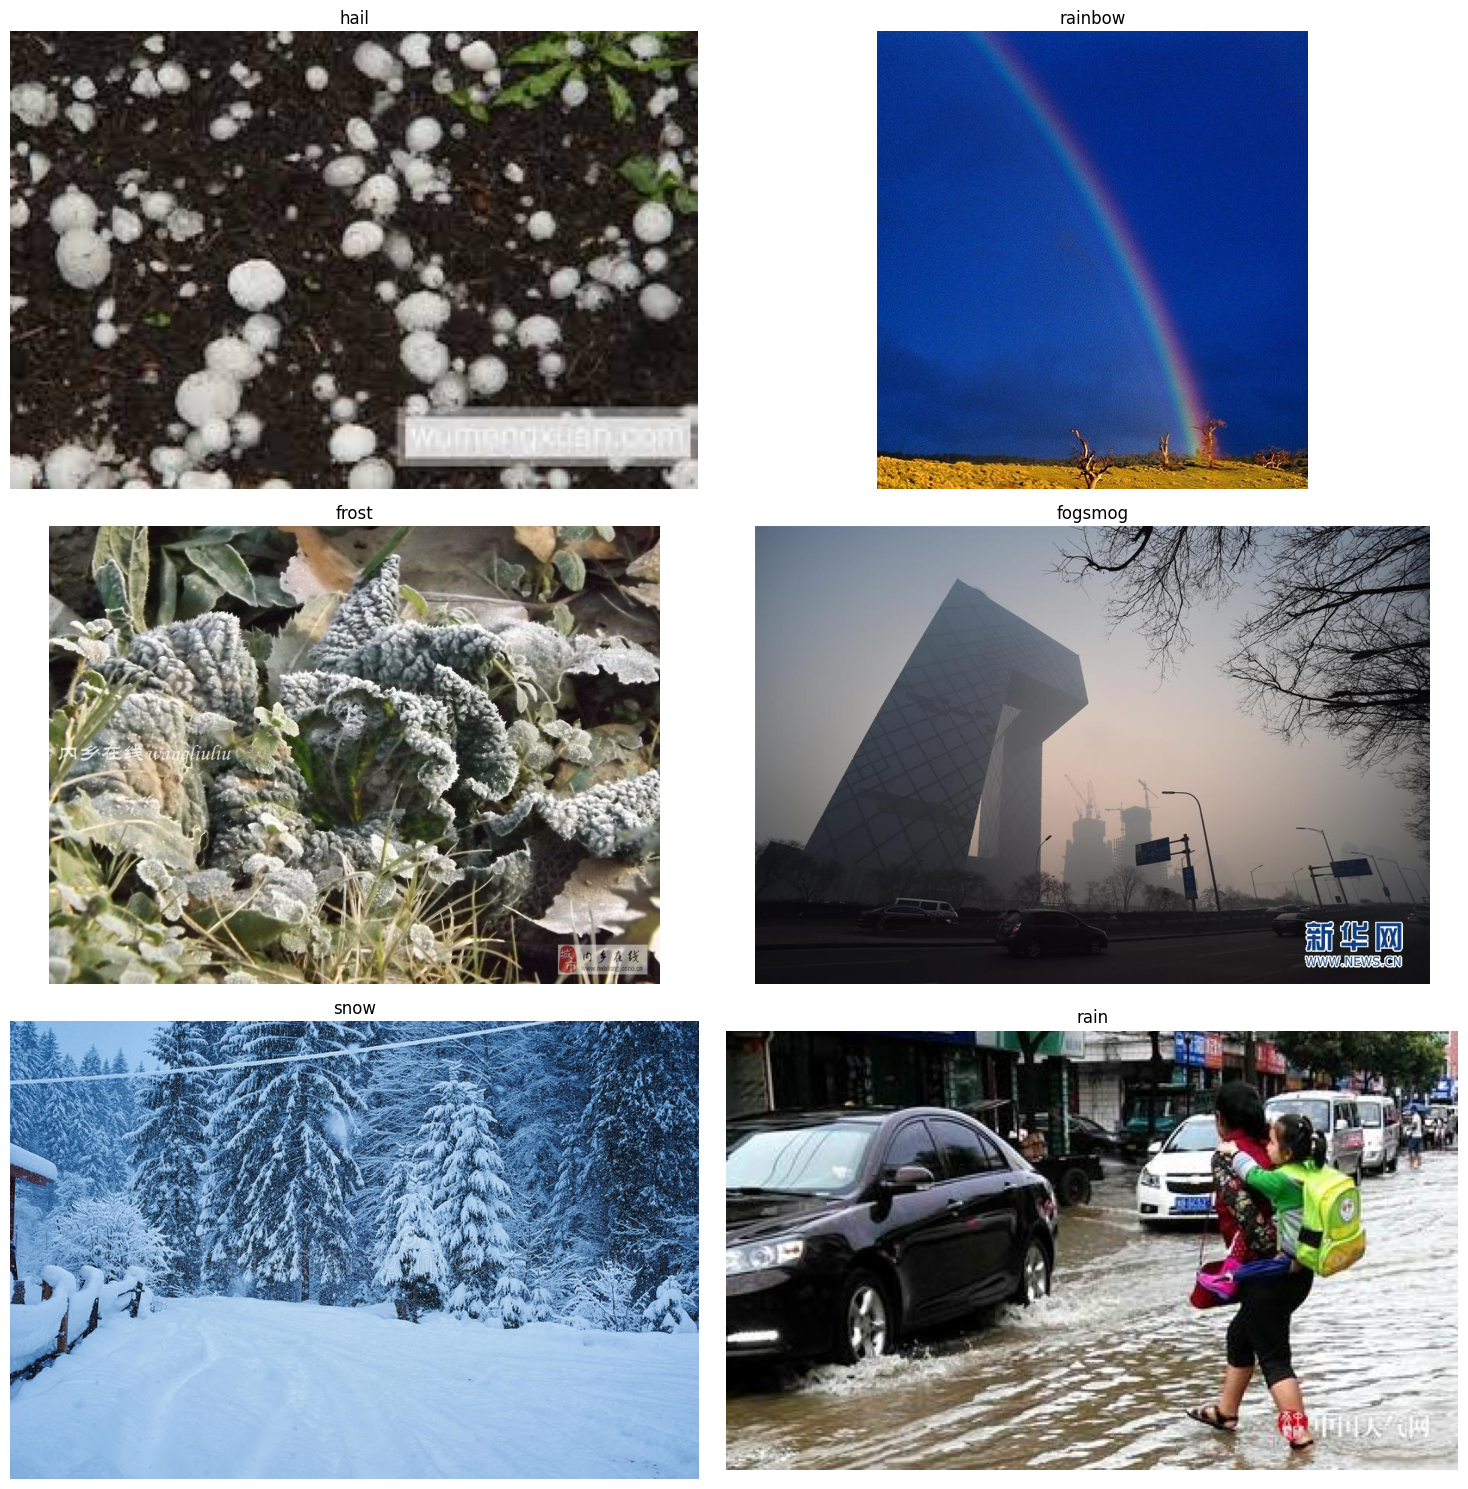

In [14]:
def show_images_in_grid():
    num_rows = 3
    num_cols = (len(weather_class) + num_rows - 1) // num_rows  # Calculate columns dynamically

    plt.figure(figsize=(15, 5 * num_rows))  # Adjust the height of the grid
    for idx, weather in enumerate(weather_class):
        image_folder_path = os.path.join(root_folder, weather)  # Use the current string `weather`
        random_file = random.choice(os.listdir(image_folder_path))
        random_image_path = os.path.join(image_folder_path, random_file)

        img = cv2.imread(random_image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        print(f'image shape {img_rgb.shape}')
        plt.subplot(num_rows, num_cols, idx + 1)  # Place the image in a grid
        plt.imshow(img_rgb)
        plt.title(weather)
        plt.axis("off")  # Hide axes for better visualization

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()

show_images_in_grid()

In [17]:
!pip install split-folders

import os
import shutil


# Create the output directory
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Loop through all classes in the original dataset
for class_name in os.listdir(root_folder):
    if class_name in weather_class:
        # Create a directory for each class in the filtered output
        class_dir = os.path.join(output_folder, class_name)
        if not os.path.exists(class_dir):
            os.makedirs(class_dir)

        # Copy the images for the current class
        class_folder = os.path.join(root_folder, class_name)
        for img_name in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_name)
            shutil.copy(img_path, class_dir)

# Now use splitfolders to split the filtered data
import splitfolders

output_folders = '/content/drive/MyDrive/ai_coursebook'
splitfolders.ratio(output_folder, output=output_folders, seed=1337, ratio=(.8, .1, .1), group_prefix=None, move=False)

print(f"Data split and saved in {output_folders}")

Copying files: 3296 files [01:48, 30.32 files/s]

Data split and saved in /content/drive/MyDrive/ai_coursebook


In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)
val_datagen = ImageDataGenerator(rescale=1/255.)

train_data = train_datagen.flow_from_directory(
    directory='/content/drive/MyDrive/ai_coursebook/train',
    target_size=(255,255),
    class_mode='categorical',
    batch_size=32,
)

test_data = test_datagen.flow_from_directory(
    directory='/content/drive/MyDrive/ai_coursebook/test',
    target_size=(255,255),
    class_mode='categorical',
    batch_size=32
)

val_data = val_datagen.flow_from_directory(
    directory = '/content/drive/MyDrive/ai_coursebook/val',
    target_size=(255,255),
    class_mode='categorical',
    batch_size=32
)

Found 2633 images belonging to 9 classes.
Found 335 images belonging to 9 classes.
Found 328 images belonging to 9 classes.


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.utils import to_categorical

# Build the CNN model with BatchNormalization
model = Sequential([
    Input(shape=(255, 255, 3)),  # Correct way to define input shape
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 253, 253, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 253, 253, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 124, 124, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,841,033 (56.61 MB)

 Trainable params: 14,840,585 (56.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Compile the model with a learning rate scheduler
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [23]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [24]:
# Train the model with additional callbacks
history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 782s 9s/step - accuracy: 0.5271 - loss: 3.5052 - val_accuracy: 0.2591 - val_loss: 10.9607
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 724s 9s/step - accuracy: 0.6537 - loss: 1.0926 - val_accuracy: 0.2591 - val_loss: 17.7496
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 718s 9s/step - accuracy: 0.6955 - loss: 0.9157 - val_accuracy: 0.2591 - val_loss: 20.5361
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 718s 8s/step - accuracy: 0.7558 - loss: 0.7251 - val_accuracy: 0.3049 - val_loss: 9.4968
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 775s 9s/step - accuracy: 0.7895 - loss: 0.6053 - val_accuracy: 0.5061 - val_loss: 4.0298
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 723s 9s/step - accuracy: 0.8204 - loss: 0.5387 - val_accuracy: 0.6951 - val_loss: 1.4052
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 696s 8s/step - accuracy: 0.8270 - loss: 0.4975 - val_accuracy: 0.7073 - val_loss: 1.1878
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 704s 8s/step - accuracy: 0.8564 - loss: 0.4056 - val_accuracy: 0.7805 

In [26]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7958 - loss: 0.9803
Test Accuracy: 80.00%


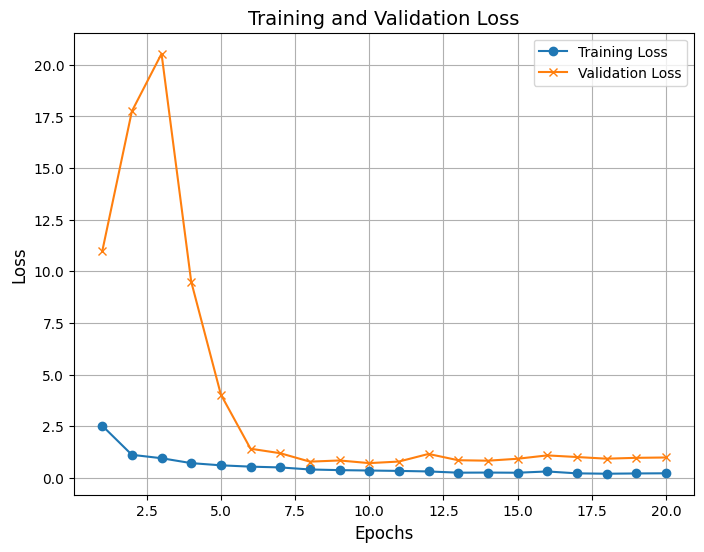

In [27]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='x')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid()
plt.show()

In [28]:
model.evaluate(val_data)

11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8402 - loss: 0.8732


[0.9807640910148621, 0.8079268336296082]

In [29]:
# Save the model
model.save('weather_cnn_model_improved.h5')

11/11 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.8103 - loss: 0.9463
Test Accuracy: 80.00%


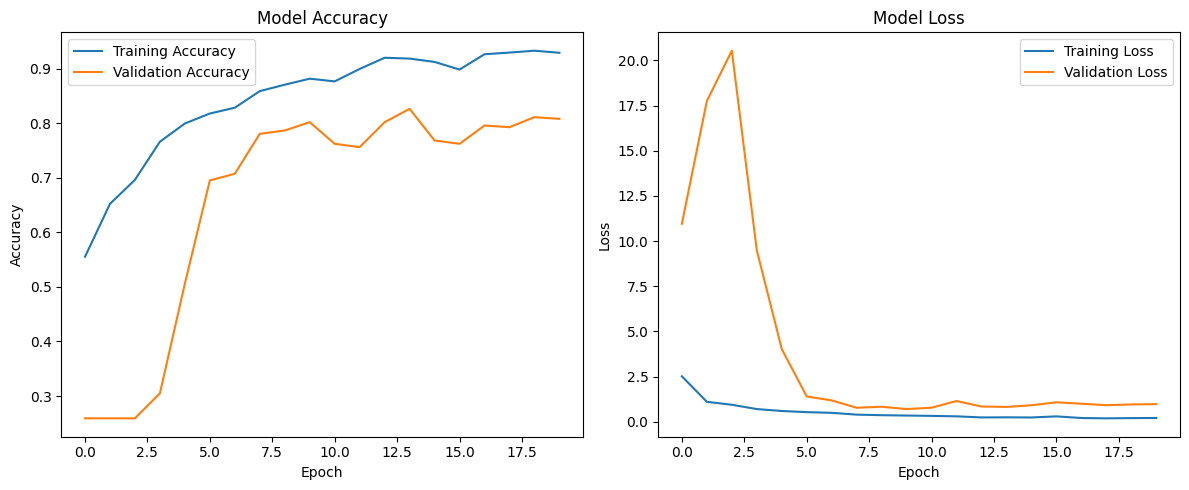

11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


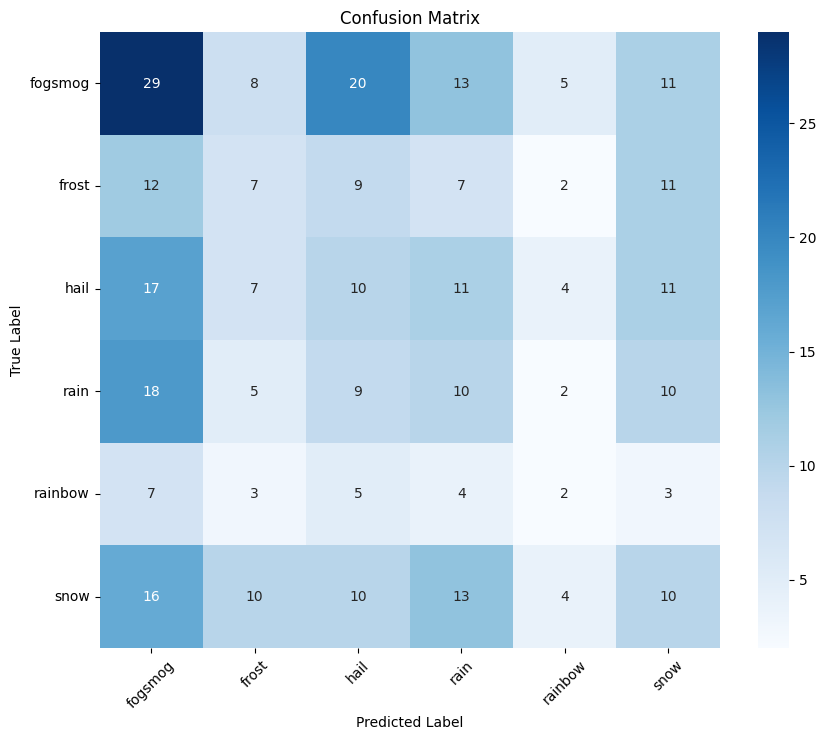

Classification Report:
              precision    recall  f1-score   support

     fogsmog       0.29      0.34      0.31        86
       frost       0.17      0.15      0.16        48
        hail       0.16      0.17      0.16        60
        rain       0.17      0.19      0.18        54
     rainbow       0.11      0.08      0.09        24
        snow       0.18      0.16      0.17        63

    accuracy                           0.20       335
   macro avg       0.18      0.18      0.18       335
weighted avg       0.20      0.20      0.20       335



In [32]:
# Evaluate the model on test set
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot training history
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Generate predictions
test_data.reset()
predictions = model.predict(test_data, steps=len(test_data), verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

# Get true classes
true_classes = test_data.classes
class_labels_full = list(test_data.class_indices.keys())
# Filter class labels to only include the classes we care about
filtered_class_labels = [label for label in class_labels_full if label in weather_class]


# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=filtered_class_labels,
            yticklabels=filtered_class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=filtered_class_labels))